# 04 — Modelado | Next Basket Recommendation
## Proyecto Final: Insight Commerce

**Input:** `data/processed/feature_matrix.parquet` — generado por `src/features/pipeline.py`  
**Output:** `models/model.pkl` — modelo serializado listo para `recommendation.py`

| Sección | Contenido |
|---|---|
| 0 | Configuración y carga |
| 1 | Validación del feature matrix |
| 2 | Split por usuarios 70/15/15 |
| 3 | K-Means como feature adicional (fit solo en train) |
| 4 | Modelo base — popularidad global |
| 5 | LightGBM baseline |
| 6 | Optuna — optimización de hiperparámetros |
| 7 | LightGBM optimizado |
| 8 | CatBoost |
| 9 | Comparativa de modelos |
| 10 | Feature importance |
| 11 | Serialización |
| 12 | Conclusiones y alertas para API |

---
> **Nota de diseño:** El split 80/20 de `preprocessing.py` es para `train.py` (producción).  
> Este notebook usa su propio split 70/15/15 **por usuarios** para tener un val set  
> limpio para Optuna. El parquet es el punto de partida — sin imputación ni escalado aplicado.

## 0. Configuración y Carga

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import mlflow
import warnings
import joblib
import json
import os
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
from mlflow.tracking import MlflowClient


import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#333333',
    'axes.grid': True, 'grid.color': '#eeeeee', 'grid.linewidth': 0.7,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'sans-serif', 'font.size': 9,
    'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'text.color': '#222222', 'axes.labelcolor': '#222222',
    'xtick.color': '#222222', 'ytick.color': '#222222',
})
P = ['#3A86FF','#FF6B6B','#06D6A0','#FFB703','#8338EC','#FB5607','#219EBC','#2DC653']

# ── Paths ──────────────────────────────────────────────────────────────────────
def find_project_root(marker='.env'):
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'No se encontro {marker} en ningun directorio padre.')

PROJECT_ROOT        = find_project_root()
load_dotenv(PROJECT_ROOT / '.env')
FEATURE_MATRIX_PATH = PROJECT_ROOT / 'data' / 'processed' / 'feature_matrix.parquet'
MODELS_PATH         = PROJECT_ROOT / 'models'
FIGURES_DIR         = PROJECT_ROOT / 'reports' / 'figures'
MODELS_PATH.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED     = int(os.getenv('RANDOM_SEED', 42))
N_OPTUNA_TRIALS = 50  # minimo acordado en card de modelado

print(f'PROJECT_ROOT         : {PROJECT_ROOT}')
print(f'FEATURE_MATRIX_PATH  : {FEATURE_MATRIX_PATH}')
print(f'RANDOM_SEED          : {RANDOM_SEED}')
print(f'N_OPTUNA_TRIALS      : {N_OPTUNA_TRIALS}')

# ── Carga ──────────────────────────────────────────────────────────────────────
assert FEATURE_MATRIX_PATH.exists(), (
    f'feature_matrix.parquet no encontrado en {FEATURE_MATRIX_PATH}\n'
    'Ejecutar primero: python -m src.features.pipeline'
)
matrix = pd.read_parquet(FEATURE_MATRIX_PATH)
print(f'\nFeature matrix cargado: {matrix.shape[0]:,} filas x {matrix.shape[1]} columnas')

# Tracking en servidor MLflow local
mlflow.set_tracking_uri("http://127.0.0.1:5000")

# ── Helper robusto para experimentos MLflow ───────────────────────────────────
client = MlflowClient()

def ensure_active_experiment(experiment_name: str):
    exp = client.get_experiment_by_name(experiment_name)
    if exp is None:
        experiment_id = client.create_experiment(experiment_name)
        exp = client.get_experiment(experiment_id)
    elif exp.lifecycle_stage == 'deleted':
        client.restore_experiment(exp.experiment_id)
        exp = client.get_experiment(exp.experiment_id)
    mlflow.set_experiment(experiment_name)
    return exp

PROJECT_ROOT         : c:\Users\julia\Data Science\Proyecto final\insight-commerce-recsys
FEATURE_MATRIX_PATH  : c:\Users\julia\Data Science\Proyecto final\insight-commerce-recsys\data\processed\feature_matrix.parquet
RANDOM_SEED          : 42
N_OPTUNA_TRIALS      : 50

Feature matrix cargado: 592,847 filas x 26 columnas


### Resultados — Sección 0
- Feature matrix cargado correctamente desde `data/processed/feature_matrix.parquet`.
- Paths y parámetros configurados desde `.env`.
- Si el assert falla, ejecutar primero `python -m src.features.pipeline`.

## 1. Validación del Feature Matrix

In [57]:
# ── Schema esperado — Feature Schema v4 ───────────────────────────────────────
EXPECTED_COLS = [
    'user_key', 'product_key',
    # usuario base
    'user_total_orders', 'user_avg_basket_size', 'user_days_since_last_order',
    # usuario extensiones
    'user_reorder_ratio', 'user_distinct_products', 'user_segment_code',
    # producto base
    'product_total_purchases', 'product_reorder_rate',
    # producto extensiones
    'product_avg_add_to_cart', 'product_unique_users',
    'p_department_reorder_rate', 'p_aisle_reorder_rate',
    # interaccion base
    'up_times_purchased', 'up_reorder_rate', 'up_orders_since_last_purchase',
    'up_first_order_number', 'up_last_order_number', 'up_avg_add_to_cart_order',
    # interaccion extensiones
    'up_days_since_last', 'up_avg_days_between_orders', 'up_delta_days',
    'u_favorite_department', 'u_favorite_aisle',
    # label
    'label',
]

# ── Validar columnas ───────────────────────────────────────────────────────────
missing_cols = [c for c in EXPECTED_COLS if c not in matrix.columns]
extra_cols   = [c for c in matrix.columns if c not in EXPECTED_COLS]

print('-- Columnas -----------------------------------------------------')
print(f'  Esperadas  : {len(EXPECTED_COLS)}')
print(f'  Presentes  : {len(matrix.columns)}')
print(f'  Faltantes  : {missing_cols if missing_cols else "ninguna OK"}')
print(f'  Extra      : {extra_cols   if extra_cols   else "ninguna OK"}')

# ── Tipos y nulos ──────────────────────────────────────────────────────────────
print('\n-- Tipos y nulos ------------------------------------------------')
val_report = pd.DataFrame({
    'dtype'  : matrix.dtypes,
    'nulls'  : matrix.isnull().sum(),
    'null_%' : (matrix.isnull().mean() * 100).round(2),
    'unique' : matrix.nunique(),
})
display(val_report)

# ── Distribucion del label ─────────────────────────────────────────────────────
label_dist = matrix['label'].value_counts().sort_index()
label_pct  = matrix['label'].value_counts(normalize=True).sort_index()
ratio      = label_dist[0] / label_dist[1]

print('\n-- Distribucion del label ---------------------------------------')
print(f'  label=0 (no reordeno) : {label_dist[0]:>8,}  ({label_pct[0]:.2%})')
print(f'  label=1 (reordeno)    : {label_dist[1]:>8,}  ({label_pct[1]:.2%})')
print(f'  Ratio 0/1             : {ratio:.2f}  -> scale_pos_weight = {ratio:.2f}')

SCALE_POS_WEIGHT = ratio  # se usa en celdas 5, 7 y 8

n_users    = matrix['user_key'].nunique()
n_products = matrix['product_key'].nunique()
print(f'\n  Usuarios unicos  : {n_users:,}')
print(f'  Productos unicos : {n_products:,}')
print(f'  Pares u x p      : {len(matrix):,}')

-- Columnas -----------------------------------------------------
  Esperadas  : 26
  Presentes  : 26
  Faltantes  : ninguna OK
  Extra      : ninguna OK

-- Tipos y nulos ------------------------------------------------


,dtype,nulls,null_%,unique
user_key,int32,0,0.00,9993
product_key,int32,0,0.00,5908
user_total_orders,int16,0,0.00,95
user_avg_basket_size,float32,0,0.00,3836
user_days_since_last_order,float32,0,0.00,31
user_reorder_ratio,float32,0,0.00,5282
user_distinct_products,int32,0,0.00,333
user_segment_code,int8,0,0.00,5
product_total_purchases,int32,0,0.00,905
product_reorder_rate,float32,0,0.00,3687



-- Distribucion del label ---------------------------------------
  label=0 (no reordeno) :  532,865  (89.88%)
  label=1 (reordeno)    :   59,982  (10.12%)
  Ratio 0/1             : 8.88  -> scale_pos_weight = 8.88

  Usuarios unicos  : 9,993
  Productos unicos : 5,908
  Pares u x p      : 592,847


### Resultados — Sección 1
- Verificar que no hay columnas faltantes ni nulos inesperados.
- `SCALE_POS_WEIGHT` calculado automáticamente desde el label real del parquet.
- NaN esperados en `up_avg_days_between_orders` y `up_delta_days` (~55%) — LightGBM los maneja nativamente.

## 2. Split por Usuarios 70/15/15

> **El split va ANTES del K-Means** para que los clusters se aprendan solo desde train,
> sin información de val ni test. De lo contrario habría leakage en las features de cluster.

In [58]:
# ── Split por usuarios ────────────────────────────────────────────────────────
# Separar por user_key — no por filas — para que el mismo usuario no aparezca
# en train y validacion al mismo tiempo (lo que generaria leakage del label).
all_users = matrix['user_key'].unique()

users_train, users_temp = train_test_split(
    all_users, test_size=0.30, random_state=RANDOM_SEED
)
users_val, users_test = train_test_split(
    users_temp, test_size=0.50, random_state=RANDOM_SEED
)

train_df = matrix[matrix['user_key'].isin(users_train)].copy()
val_df   = matrix[matrix['user_key'].isin(users_val)].copy()
test_df  = matrix[matrix['user_key'].isin(users_test)].copy()

# ── Features y labels ──────────────────────────────────────────────────────────
# user_cluster y product_cluster se agregan en Seccion 3 — por ahora excluidos
ID_COLS      = ['user_key', 'product_key']
LABEL_COL    = 'label'
FEATURE_COLS = [c for c in matrix.columns if c not in ID_COLS + [LABEL_COL]]

X_train, y_train = train_df[FEATURE_COLS], train_df[LABEL_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[LABEL_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[LABEL_COL]

print('-- Split por usuarios -------------------------------------------')
print(f'  Train      : {len(users_train):>6,} usuarios  |  {len(train_df):>8,} pares  |  label=1: {y_train.mean():.2%}')
print(f'  Validacion : {len(users_val):>6,}   usuarios  |  {len(val_df):>8,} pares  |  label=1: {y_val.mean():.2%}')
print(f'  Test       : {len(users_test):>6,}   usuarios  |  {len(test_df):>8,} pares  |  label=1: {y_test.mean():.2%}')
print(f'\n  Features base (sin clusters aun) : {len(FEATURE_COLS)}')

-- Split por usuarios -------------------------------------------
  Train      :  6,995 usuarios  |   416,995 pares  |  label=1: 10.15%
  Validacion :  1,499   usuarios  |    87,228 pares  |  label=1: 10.13%
  Test       :  1,499   usuarios  |    88,624 pares  |  label=1: 9.95%

  Features base (sin clusters aun) : 23


### Resultados — Sección 2
- Split por usuarios garantiza que no hay data leakage entre conjuntos.
- La proporción de `label=1` debe ser similar en los tres conjuntos (~10%).

## 3. K-Means como Feature Adicional

> **Fit solo en train, transform en val y test** — igual que cualquier otro transformador.

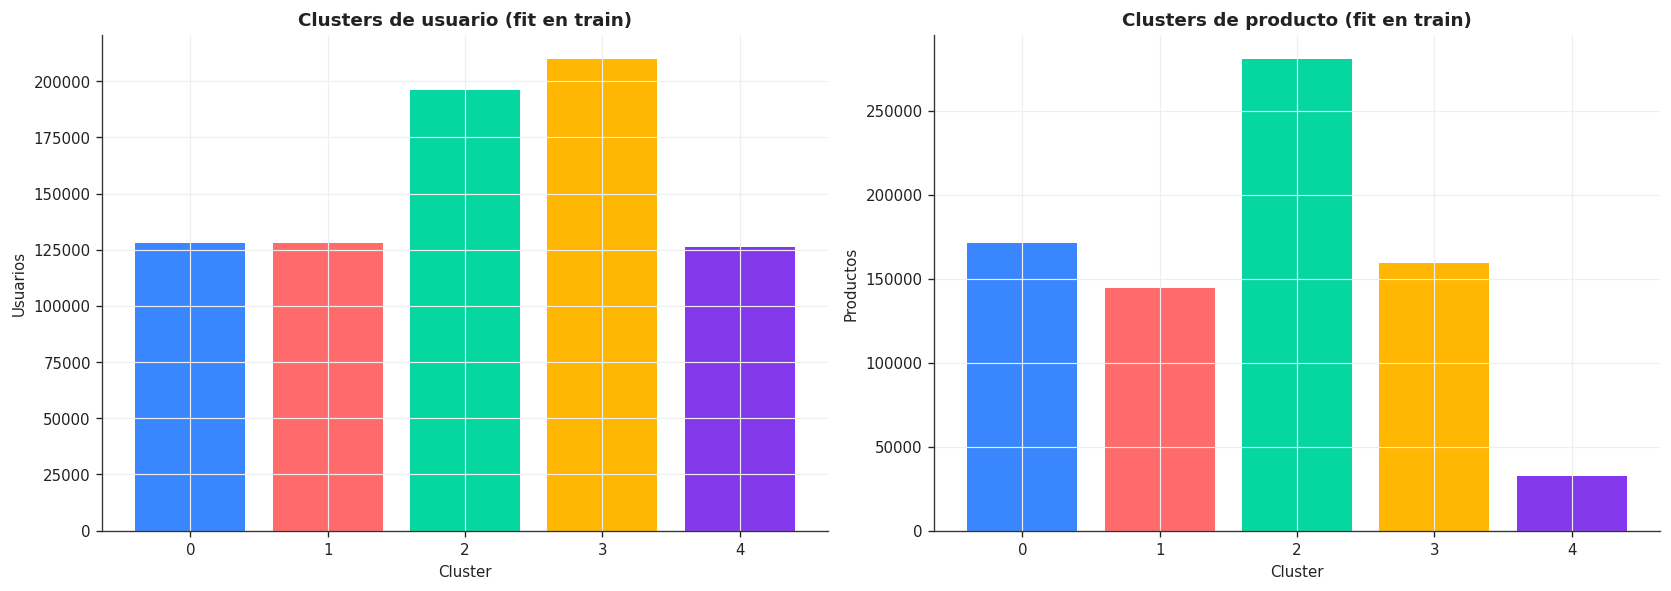

user_cluster    : 5 clusters | fit en 6,995 usuarios de train
product_cluster : 5 clusters | fit en 5,907 productos de train
FEATURE_COLS totales (con clusters) : 25
['user_total_orders', 'user_avg_basket_size', 'user_days_since_last_order', 'user_reorder_ratio', 'user_distinct_products', 'user_segment_code', 'product_total_purchases', 'product_reorder_rate', 'product_avg_add_to_cart', 'product_unique_users', 'p_department_reorder_rate', 'p_aisle_reorder_rate', 'up_times_purchased', 'up_reorder_rate', 'up_orders_since_last_purchase', 'up_first_order_number', 'up_last_order_number', 'up_avg_add_to_cart_order', 'up_days_since_last', 'up_avg_days_between_orders', 'up_delta_days', 'u_favorite_department', 'u_favorite_aisle', 'user_cluster', 'product_cluster']


In [59]:
# ── K-Means sobre features de usuario ─────────────────────────────────────────
USER_CLUSTER_FEATURES = [
    'user_total_orders', 'user_avg_basket_size',
    'user_days_since_last_order', 'user_reorder_ratio',
    'user_distinct_products',
]
N_CLUSTERS_USER = 5  # consistente con user_segment_code del Feature Schema

# Registrar parámetros de clustering en MLflow
# mlflow.log_param("n_clusters_user", N_CLUSTERS_USER)
# mlflow.log_param("user_cluster_features", USER_CLUSTER_FEATURES)

# Perfil por usuario — solo desde train
user_profiles_train = train_df.groupby('user_key')[USER_CLUSTER_FEATURES].mean()
scaler_user         = StandardScaler()
user_scaled_train   = scaler_user.fit_transform(user_profiles_train)

kmeans_user = KMeans(n_clusters=N_CLUSTERS_USER, random_state=RANDOM_SEED, n_init=10)
kmeans_user.fit(user_scaled_train)

# Asignar cluster a cada split
def assign_user_cluster(df, user_profiles_train, scaler, kmeans):
    """Asigna cluster de usuario. Usuarios no vistos en train reciben cluster -1."""
    profiles = df.groupby('user_key')[USER_CLUSTER_FEATURES].mean()
    known    = profiles.index.isin(user_profiles_train.index)
    clusters = pd.Series(-1, index=profiles.index, name='user_cluster')
    if known.any():
        scaled = scaler.transform(profiles[known])
        clusters[known] = kmeans.predict(scaled)
    return df.merge(clusters.reset_index(), on='user_key', how='left')

train_df = assign_user_cluster(train_df, user_profiles_train, scaler_user, kmeans_user)
val_df   = assign_user_cluster(val_df,   user_profiles_train, scaler_user, kmeans_user)
test_df  = assign_user_cluster(test_df,  user_profiles_train, scaler_user, kmeans_user)

# ── K-Means sobre features de producto ────────────────────────────────────────
PRODUCT_CLUSTER_FEATURES = [
    'product_total_purchases', 'product_reorder_rate',
    'product_avg_add_to_cart', 'product_unique_users',
    'p_department_reorder_rate',
]
N_CLUSTERS_PRODUCT = 5

# mlflow.log_param("n_clusters_product", N_CLUSTERS_PRODUCT)
# mlflow.log_param("product_cluster_features", PRODUCT_CLUSTER_FEATURES)

product_profiles_train = train_df.groupby('product_key')[PRODUCT_CLUSTER_FEATURES].mean()
scaler_product         = StandardScaler()
product_scaled_train   = scaler_product.fit_transform(
    product_profiles_train.fillna(product_profiles_train.median())
)

kmeans_product = KMeans(n_clusters=N_CLUSTERS_PRODUCT, random_state=RANDOM_SEED, n_init=10)
kmeans_product.fit(product_scaled_train)

def assign_product_cluster(df, product_profiles_train, scaler, kmeans):
    """Asigna cluster de producto. Productos no vistos en train reciben cluster -1."""
    profiles = df.groupby('product_key')[PRODUCT_CLUSTER_FEATURES].mean()
    known    = profiles.index.isin(product_profiles_train.index)
    clusters = pd.Series(-1, index=profiles.index, name='product_cluster')
    if known.any():
        scaled = scaler.transform(profiles[known].fillna(profiles[known].median()))
        clusters[known] = kmeans.predict(scaled)
    return df.merge(clusters.reset_index(), on='product_key', how='left')

train_df = assign_product_cluster(train_df, product_profiles_train, scaler_product, kmeans_product)
val_df   = assign_product_cluster(val_df,   product_profiles_train, scaler_product, kmeans_product)
test_df  = assign_product_cluster(test_df,  product_profiles_train, scaler_product, kmeans_product)

# Castear a int8
for df in [train_df, val_df, test_df]:
    df['user_cluster']    = df['user_cluster'].astype('int8')
    df['product_cluster'] = df['product_cluster'].astype('int8')

# ── Actualizar FEATURE_COLS con los clusters ───────────────────────────────────
FEATURE_COLS = [c for c in train_df.columns if c not in ID_COLS + [LABEL_COL]]

X_train, y_train = train_df[FEATURE_COLS], train_df[LABEL_COL]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[LABEL_COL]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[LABEL_COL]

# ── Visualizacion ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

user_cc = train_df['user_cluster'].value_counts().sort_index()
axes[0].bar(user_cc.index, user_cc.values, color=P[:N_CLUSTERS_USER])
axes[0].set_title('Clusters de usuario (fit en train)', fontweight='bold')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Usuarios')

prod_cc = train_df['product_cluster'].value_counts().sort_index()
axes[1].bar(prod_cc.index, prod_cc.values, color=P[:N_CLUSTERS_PRODUCT])
axes[1].set_title('Clusters de producto (fit en train)', fontweight='bold')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Productos')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_kmeans_clusters.png', bbox_inches='tight')
plt.show()

print(f'user_cluster    : {N_CLUSTERS_USER} clusters | fit en {len(user_profiles_train):,} usuarios de train')
print(f'product_cluster : {N_CLUSTERS_PRODUCT} clusters | fit en {len(product_profiles_train):,} productos de train')
print(f'FEATURE_COLS totales (con clusters) : {len(FEATURE_COLS)}')
print(f'{FEATURE_COLS}')

In [60]:
def eval_metrics(y_true, y_pred, name, y_proba=None):
        m = {
            'modelo'    : name,
            'precision' : precision_score(y_true, y_pred, zero_division=0),
            'recall'    : recall_score(y_true, y_pred, zero_division=0),
            'f1'        : f1_score(y_true, y_pred, zero_division=0),
        }
        if y_proba is not None:
            m['auc'] = roc_auc_score(y_true, y_proba)
        return m

### Resultados — Sección 3
- K-Means fiteado **solo en train**, transformado en val y test por separado — sin leakage.
- Usuarios/productos no vistos en train reciben cluster `-1` (manejado por LightGBM y CatBoost como categórica válida).
- `user_cluster` complementa `user_segment_code` — captura patrones multidimensionales.
- Si la distribución de clusters es muy desigual, evaluar aumentar `N_CLUSTERS_USER` o `N_CLUSTERS_PRODUCT`.

## 4. Modelo Base — Popularidad Global

In [61]:
# ── Baseline: productos mas populares globalmente ─────────────────────────────
# No usa historial del usuario — benchmark minimo que cualquier modelo debe superar.
# Popularidad = cantidad de compras del producto en el conjunto de train.

ensure_active_experiment("Baseline popularidad")

TOP_K = 10
mlflow.end_run()

with mlflow.start_run(run_name="Baseline popularidad"):
    mlflow.log_param("estrategia", "Popularidad Global")
    mlflow.log_param("TOP_K", TOP_K)
    
    product_popularity  = (
        train_df.groupby('product_key')['product_total_purchases']
        .mean()
        .sort_values(ascending=False)
    )
    top_products_global = set(product_popularity.head(TOP_K).index)

    def baseline_predict(df, top_products):
        return df['product_key'].isin(top_products).astype(int)

    y_pred_baseline_val  = baseline_predict(val_df,  top_products_global)
    y_pred_baseline_test = baseline_predict(test_df, top_products_global)

    baseline_metrics = eval_metrics(y_test, y_pred_baseline_test, 'Baseline popularidad')
    results = [baseline_metrics]

    mlflow.log_metric("precision", baseline_metrics['precision'])
    mlflow.log_metric("recall", baseline_metrics['recall'])
    mlflow.log_metric("f1", baseline_metrics['f1'])
    if 'auc' in baseline_metrics:
        mlflow.log_metric("auc", baseline_metrics['auc'])

print('-- Modelo Base - Popularidad Global ----------------------------')
print(f"  Precision : {baseline_metrics['precision']:.4f}")
print(f"  Recall    : {baseline_metrics['recall']:.4f}")
print(f"  F1        : {baseline_metrics['f1']:.4f}")
print(f'\n  Top {TOP_K} productos globales usados como recomendacion.')
print('  Este es el benchmark minimo -- todos los modelos deben superarlo.')

2026/03/18 13:09:15 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/18 13:09:15 INFO mlflow.store.db.utils: Updating database tables
2026/03/18 13:09:23 INFO mlflow.tracking.fluent: Experiment with name 'Recomendacion_Proxima_Compra' does not exist. Creating a new experiment.


🏃 View run smiling-dolphin-645 at: http://127.0.0.1:5000/#/experiments/3/runs/0d10e772648d46b6a41ca1c24688971d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
🏃 View run Baseline popularidad at: http://127.0.0.1:5000/#/experiments/2/runs/4ef88d5f5f5d4ba2af0f0996386e495b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/2
-- Modelo Base - Popularidad Global ----------------------------
  Precision : 0.2370
  Recall    : 0.1159
  F1        : 0.1557

  Top 10 productos globales usados como recomendacion.
  Este es el benchmark minimo -- todos los modelos deben superarlo.


### Resultados — Sección 4
- El baseline recomienda los mismos productos a todos los usuarios sin considerar historial.
- F1 esperado: bajo (0.05–0.15). Si es mayor, revisar si hay leakage.
- Este número es el piso que LightGBM debe superar.

## 5. LightGBM Baseline

In [62]:
# ── Features categoricas para LightGBM ────────────────────────────────────────
# LightGBM maneja enteros como categoricas si se declaran explicitamente.
mlflow.end_run()
ensure_active_experiment("LightGBM Baselines")

LGBM_CAT_FEATURES = [
    'user_segment_code', 'u_favorite_department', 'u_favorite_aisle',
    'user_cluster', 'product_cluster',
]
# Solo las que existen en FEATURE_COLS
lgbm_cat = [c for c in LGBM_CAT_FEATURES if c in FEATURE_COLS]

with mlflow.start_run(run_name="LightGBM baseline"):
    mlflow.log_param("model_type", "LightGBM baseline")
    mlflow.log_param("categorical_features", lgbm_cat)

    lgbm_baseline = lgb.LGBMClassifier(
        n_estimators     = 500,
        learning_rate    = 0.05,
        num_leaves       = 63,
        scale_pos_weight = SCALE_POS_WEIGHT,
        random_state     = RANDOM_SEED,
        n_jobs           = -1,
        verbose          = -1,
    )
    lgbm_baseline.fit(
        X_train, y_train,
        eval_set              = [(X_val, y_val)],
        categorical_feature   = lgbm_cat,
        callbacks             = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
    )

    y_pred_lgbm_bl       = lgbm_baseline.predict(X_test)
    y_pred_proba_lgbm_bl = lgbm_baseline.predict_proba(X_test)[:, 1]

    lgbm_bl_metrics = eval_metrics(y_test, y_pred_lgbm_bl, 'LightGBM baseline', y_pred_proba_lgbm_bl)
    results.append(lgbm_bl_metrics)

    mlflow.log_metric("precision", lgbm_bl_metrics['precision'])
    mlflow.log_metric("recall", lgbm_bl_metrics['recall'])
    mlflow.log_metric("f1", lgbm_bl_metrics['f1'])
    if 'auc' in lgbm_bl_metrics:
        mlflow.log_metric("auc", lgbm_bl_metrics['auc'])

print('-- LightGBM Baseline -------------------------------------------')
print(f"  Precision : {lgbm_bl_metrics['precision']:.4f}")
print(f"  Recall    : {lgbm_bl_metrics['recall']:.4f}")
print(f"  F1        : {lgbm_bl_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {lgbm_bl_metrics['auc']:.4f}")
print(f'\n  Best iteration     : {lgbm_baseline.best_iteration_}')
print(f'  Cat features usadas: {lgbm_cat}')

2026/03/18 13:09:23 INFO mlflow.tracking.fluent: Experiment with name 'LightGBM Baselines' does not exist. Creating a new experiment.


🏃 View run LightGBM baseline at: http://127.0.0.1:5000/#/experiments/3/runs/943508a9aa924b778ae3733624e624e7
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
-- LightGBM Baseline -------------------------------------------
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000
  AUC-ROC   : 0.8257

  Best iteration     : 4
  Cat features usadas: ['user_segment_code', 'u_favorite_department', 'u_favorite_aisle', 'user_cluster', 'product_cluster']


### Resultados — Sección 5
- LightGBM baseline con hiperparámetros conservadores.
- `scale_pos_weight` calculado automáticamente desde el label real (Sección 1).
- `early_stopping(50)` detiene si no mejora en 50 rondas sobre val.
- AUC-ROC > 0.75 es un buen punto de partida.

## 6. Optuna — Optimización de Hiperparámetros

  0%|          | 0/50 [00:00<?, ?it/s]


-- Optuna - Mejor trial ----------------------------------------
  F1 validacion : 0.3852
  Parametros:
    n_estimators             : 639
    learning_rate            : 0.2959007055890211
    num_leaves               : 136
    max_depth                : 10
    min_child_samples        : 88
    subsample                : 0.5940707288690343
    colsample_bytree         : 0.9792404814884555
    reg_alpha                : 3.069562908474676e-07
    reg_lambda               : 0.10767679910314054
    scale_pos_weight         : 10.195995298041856
    random_state             : 42
    n_jobs                   : -1
    verbose                  : -1


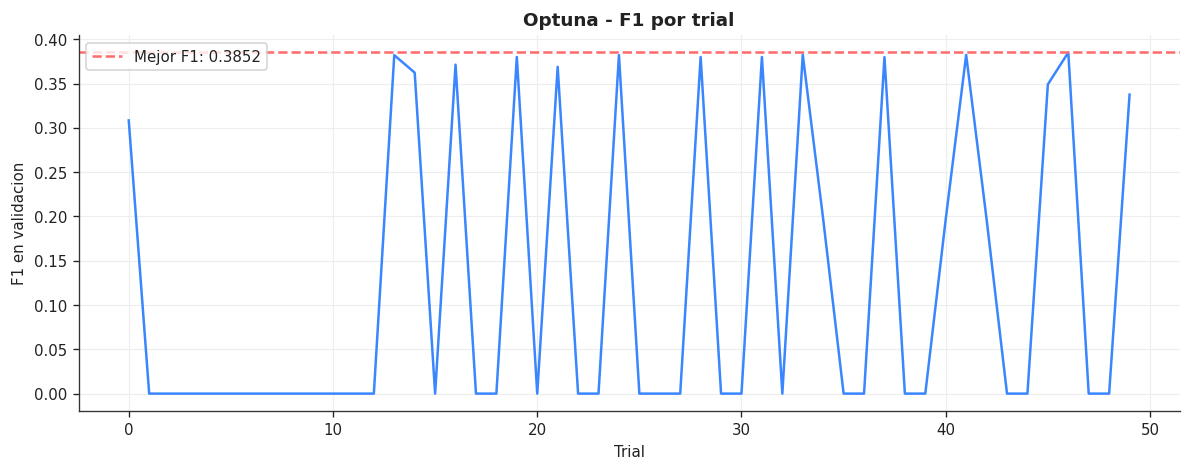

In [63]:
def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'         : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples' : trial.suggest_int('min_child_samples', 10, 100),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'scale_pos_weight'  : SCALE_POS_WEIGHT,
        'random_state'      : RANDOM_SEED,
        'n_jobs'            : -1,
        'verbose'           : -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set            = [(X_val, y_val)],
        categorical_feature = lgbm_cat,
        callbacks           = [lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, zero_division=0)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_state'    : RANDOM_SEED,
    'n_jobs'          : -1,
    'verbose'         : -1,
})

print(f'\n-- Optuna - Mejor trial ----------------------------------------')
print(f'  F1 validacion : {study.best_value:.4f}')
print(f'  Parametros:')
for k, v in best_params.items():
    print(f'    {k:<25s}: {v}')

# ── Visualizacion ──────────────────────────────────────────────────────────────
trial_values = [t.value for t in study.trials]
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trial_values, color=P[0], lw=1.5)
ax.axhline(max(trial_values), color=P[1], lw=1.5, ls='--',
           label=f'Mejor F1: {max(trial_values):.4f}')
ax.set_title('Optuna - F1 por trial', fontweight='bold')
ax.set_xlabel('Trial'); ax.set_ylabel('F1 en validacion')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_optuna_trials.png', bbox_inches='tight')
plt.show()

### Resultados — Sección 6
- Búsqueda bayesiana con TPE Sampler sobre 50 trials mínimo.
- Métrica de optimización: F1 en conjunto de validación (no en test — sin leakage).
- Los mejores parámetros se usan directamente en Sección 7.
- Si el F1 no mejora después de 20 trials, el modelo ya está cerca del óptimo.

## 7. LightGBM Optimizado

In [64]:
mlflow.end_run()
ensure_active_experiment("LightGBM Baselines")

with mlflow.start_run(run_name="LightGBM optimizado"):
    mlflow.log_param("model_type", "LightGBM optimizado")
    mlflow.log_params(best_params)

    lgbm_opt = lgb.LGBMClassifier(**best_params)
    lgbm_opt.fit(
        X_train, y_train,
        eval_set            = [(X_val, y_val)],
        categorical_feature = lgbm_cat,
        callbacks           = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)],
    )

    y_pred_lgbm_opt       = lgbm_opt.predict(X_test)
    y_pred_proba_lgbm_opt = lgbm_opt.predict_proba(X_test)[:, 1]

    lgbm_opt_metrics = eval_metrics(y_test, y_pred_lgbm_opt, 'LightGBM optimizado', y_pred_proba_lgbm_opt)
    results.append(lgbm_opt_metrics)

    mlflow.log_metric("precision", lgbm_opt_metrics['precision'])
    mlflow.log_metric("recall", lgbm_opt_metrics['recall'])
    mlflow.log_metric("f1", lgbm_opt_metrics['f1'])
    if 'auc' in lgbm_opt_metrics:
        mlflow.log_metric("auc", lgbm_opt_metrics['auc'])

print('-- LightGBM Optimizado -----------------------------------------')
print(f"  Precision : {lgbm_opt_metrics['precision']:.4f}")
print(f"  Recall    : {lgbm_opt_metrics['recall']:.4f}")
print(f"  F1        : {lgbm_opt_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {lgbm_opt_metrics['auc']:.4f}")
print(f'\n  Best iteration : {lgbm_opt.best_iteration_}')
print(f"  Mejora F1 vs baseline : {lgbm_opt_metrics['f1'] - lgbm_bl_metrics['f1']:+.4f}")

🏃 View run LightGBM optimizado at: http://127.0.0.1:5000/#/experiments/3/runs/ebeaa99c348a4d5fbbd0586ce2724016
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
-- LightGBM Optimizado -----------------------------------------
  Precision : 0.3626
  Recall    : 0.4602
  F1        : 0.4056
  AUC-ROC   : 0.8134

  Best iteration : 1
  Mejora F1 vs baseline : +0.4056


### Resultados — Sección 7
- LightGBM reentrenado con los mejores hiperparámetros de Optuna.
- Comparar F1 vs baseline para cuantificar la mejora de la optimización.
- Este modelo es el candidato principal para producción.

## 8. CatBoost

In [65]:
# ── Features categoricas para CatBoost ────────────────────────────────────────
# CatBoost las recibe como indices de columna o nombres — usamos indices.
CAT_FEATURES_CB = [
    'user_segment_code', 'u_favorite_department', 'u_favorite_aisle',
    'user_cluster', 'product_cluster',
]
cat_features_idx = [FEATURE_COLS.index(c) for c in CAT_FEATURES_CB if c in FEATURE_COLS]

mlflow.end_run()
ensure_active_experiment("CatBoost Baselines")

with mlflow.start_run(run_name="CatBoost baseline"):
    mlflow.set_tag("model_type", "CatBoost")
    mlflow.log_param("categorical_features", [FEATURE_COLS[i] for i in cat_features_idx])

    catboost_model = CatBoostClassifier(
        iterations            = 500,
        learning_rate         = 0.05,
        depth                 = 6,
        scale_pos_weight      = SCALE_POS_WEIGHT,
        random_seed           = RANDOM_SEED,
        cat_features          = cat_features_idx,
        eval_metric           = 'F1',
        early_stopping_rounds = 50,
        verbose               = 100,
    )
    catboost_model.fit(
        X_train, y_train,
        eval_set=(X_val, y_val),
    )

    y_pred_cat       = catboost_model.predict(X_test)
    y_pred_proba_cat = catboost_model.predict_proba(X_test)[:, 1]

    cat_metrics = eval_metrics(y_test, y_pred_cat, 'CatBoost', y_pred_proba_cat)
    results.append(cat_metrics)

    mlflow.log_metric("precision", cat_metrics['precision'])
    mlflow.log_metric("recall", cat_metrics['recall'])
    mlflow.log_metric("f1", cat_metrics['f1'])
    if 'auc' in cat_metrics:
        mlflow.log_metric("auc", cat_metrics['auc'])

    mlflow.catboost.log_model(catboost_model, artifact_path="modelo_catboost")

print('-- CatBoost ----------------------------------------------------')
print(f"  Precision : {cat_metrics['precision']:.4f}")
print(f"  Recall    : {cat_metrics['recall']:.4f}")
print(f"  F1        : {cat_metrics['f1']:.4f}")
print(f"  AUC-ROC   : {cat_metrics['auc']:.4f}")
print(f'\n  Cat features idx: {cat_features_idx}')
print(f'  Cat features nombres: {[FEATURE_COLS[i] for i in cat_features_idx]}')

0:	learn: 0.7405643	test: 0.7340136	best: 0.7340136 (0)	total: 915ms	remaining: 7m 36s
100:	learn: 0.7456990	test: 0.7410237	best: 0.7418535 (69)	total: 1m 33s	remaining: 6m 10s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.7418535375
bestIteration = 69

Shrink model to first 70 iterations.


2026/03/18 20:45:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run CatBoost baseline at: http://127.0.0.1:5000/#/experiments/4/runs/39079e114ead4f5781ce504d536470c3
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4
-- CatBoost ----------------------------------------------------
  Precision : 0.2205
  Recall    : 0.7617
  F1        : 0.3420
  AUC-ROC   : 0.8198

  Cat features idx: [5, 21, 22, 23, 24]
  Cat features nombres: ['user_segment_code', 'u_favorite_department', 'u_favorite_aisle', 'user_cluster', 'product_cluster']


### Resultados — Sección 8
- CatBoost maneja `user_segment_code`, `u_favorite_department`, `u_favorite_aisle`, `user_cluster` y `product_cluster` como categóricas sin encoding explícito.
- Comparar F1 y AUC vs LightGBM optimizado para decidir el modelo de producción.

## 9. Comparativa de Modelos

-- Comparativa de Modelos --------------------------------------


,precision,recall,f1,auc
modelo,,,,
Baseline popularidad,0.2090,0.0998,0.1351,nan
LightGBM baseline,0.0000,0.0000,0.0000,0.8160
LightGBM optimizado,0.3626,0.4602,0.4056,0.8134
CatBoost,0.2205,0.7617,0.3420,0.8198


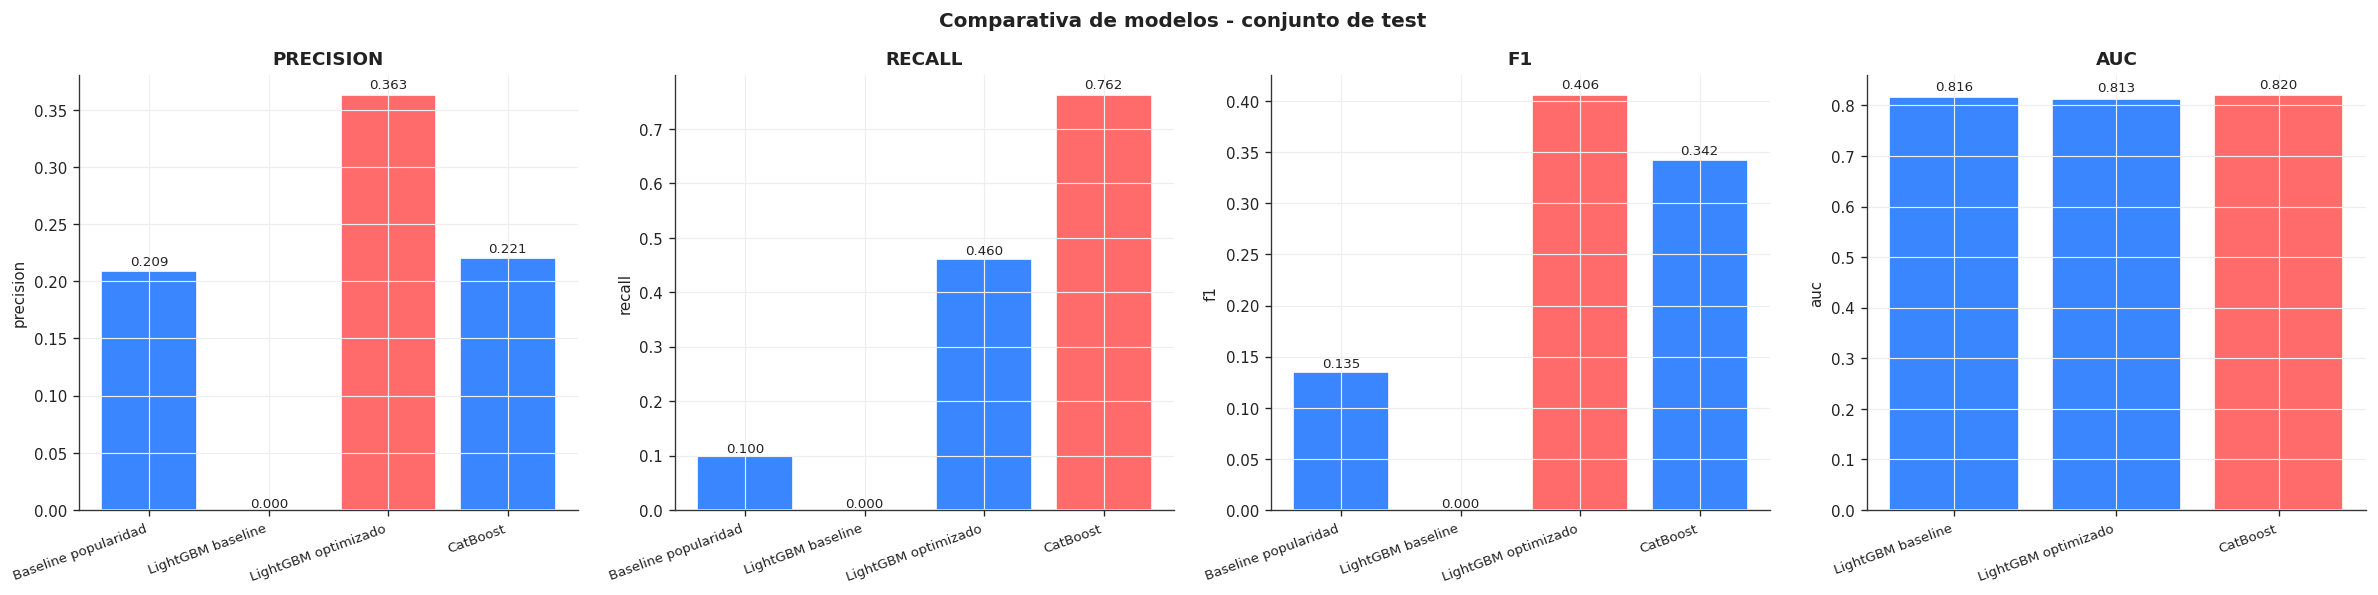


Modelo ganador por F1: LightGBM optimizado
AUC-ROC del ganador  : 0.8134


In [66]:
results_df = pd.DataFrame(results).set_index('modelo').round(4)

print('-- Comparativa de Modelos --------------------------------------')
display(results_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

# ── Grafico comparativo ────────────────────────────────────────────────────────
metrics_to_plot = [m for m in ['precision', 'recall', 'f1', 'auc'] if m in results_df.columns]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(5 * len(metrics_to_plot), 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals   = results_df[metric].dropna()
    colors = [P[1] if v == vals.max() else P[0] for v in vals.values]
    bars   = ax.bar(vals.index, vals.values, color=colors, edgecolor='white')
    ax.set_title(metric.upper(), fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_xticklabels(vals.index, rotation=20, ha='right', fontsize=8)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparativa de modelos - conjunto de test', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_model_comparison.png', bbox_inches='tight')
plt.show()

# ── Modelo ganador ─────────────────────────────────────────────────────────────
best_model_name = results_df['f1'].idxmax()
print(f'\nModelo ganador por F1: {best_model_name}')
if 'auc' in results_df.columns:
    print(f'AUC-ROC del ganador  : {results_df.loc[best_model_name, "auc"]:.4f}')

### Resultados — Sección 9
- Verde = mejor valor por métrica.
- El modelo ganador se serializa en Sección 11.
- Si LightGBM optimizado y CatBoost empatan en F1, usar AUC-ROC como desempate.

## 10. Feature Importance

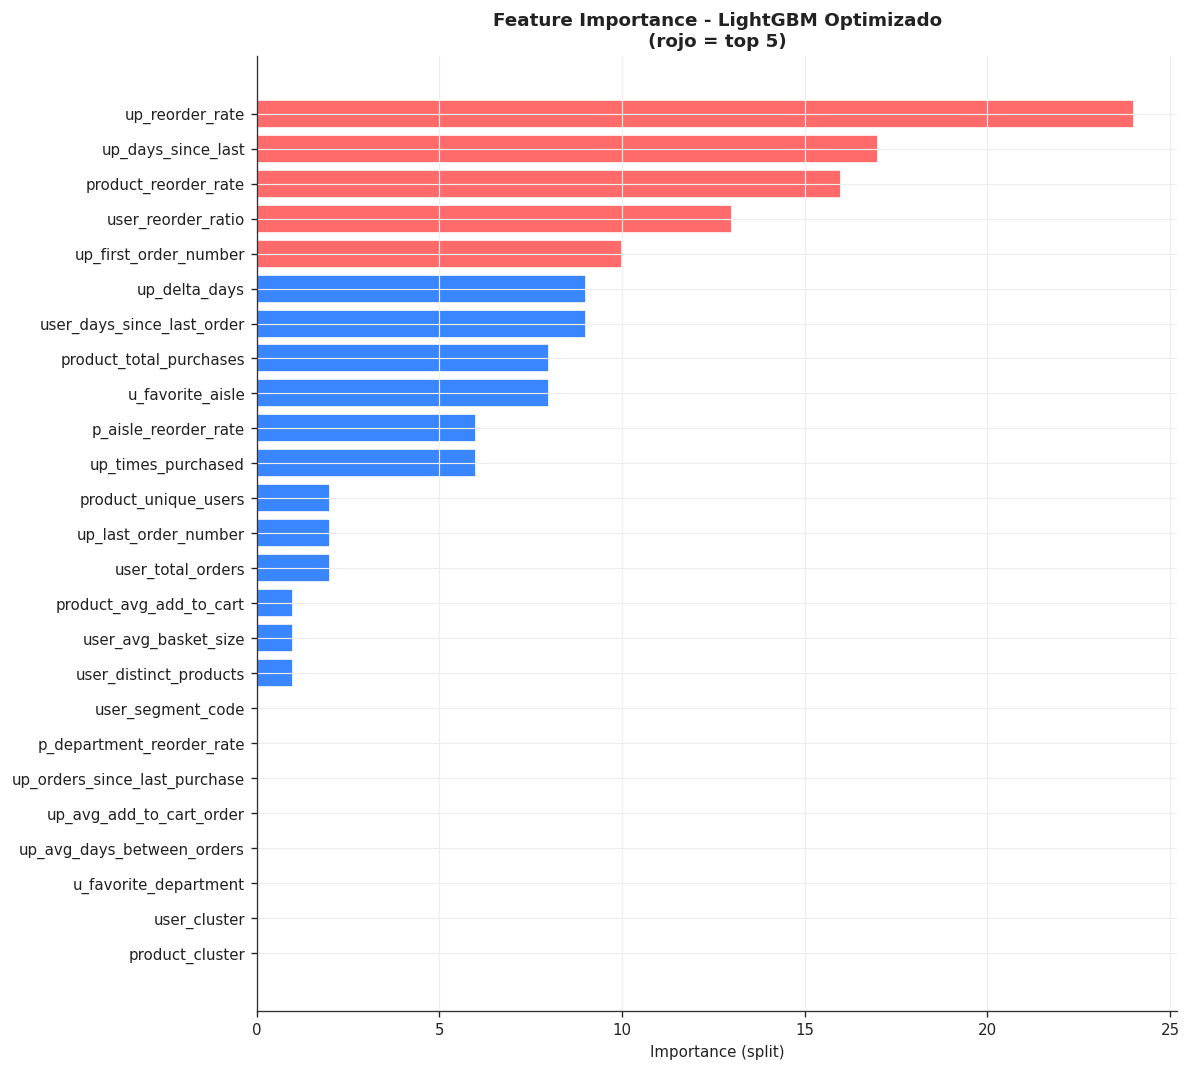

-- Top 10 features mas importantes ----------------------------
                   feature  importance
           up_reorder_rate          24
        up_days_since_last          17
      product_reorder_rate          16
        user_reorder_ratio          13
     up_first_order_number          10
             up_delta_days           9
user_days_since_last_order           9
   product_total_purchases           8
          u_favorite_aisle           8
      p_aisle_reorder_rate           6

-- Bottom 5 features menos importantes -----------------------
                   feature  importance
  up_avg_add_to_cart_order           0
up_avg_days_between_orders           0
     u_favorite_department           0
              user_cluster           0
           product_cluster           0

Features con importance=0 (candidatas a eliminar): ['user_segment_code', 'p_department_reorder_rate', 'up_orders_since_last_purchase', 'up_avg_add_to_cart_order', 'up_avg_days_between_orders', 'u_favorite_dep

In [67]:
# ── Feature importance - LightGBM optimizado ──────────────────────────────────
importance_df = pd.DataFrame({
    'feature'    : FEATURE_COLS,
    'importance' : lgbm_opt.feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 9))
colors  = [P[1] if i < 5 else P[0] for i in range(len(importance_df))]
ax.barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance - LightGBM Optimizado\n(rojo = top 5)', fontweight='bold')
ax.set_xlabel('Importance (split)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_feature_importance.png', bbox_inches='tight')
plt.show()

print('-- Top 10 features mas importantes ----------------------------')
print(importance_df.head(10).to_string(index=False))
print('\n-- Bottom 5 features menos importantes -----------------------')
print(importance_df.tail(5).to_string(index=False))

zero_imp = importance_df[importance_df['importance'] == 0]['feature'].tolist()
if zero_imp:
    print(f'\nFeatures con importance=0 (candidatas a eliminar): {zero_imp}')
else:
    print('\nTodas las features tienen importance > 0.')

### Resultados — Sección 10
- Features de interacción u×p suelen dominar el top: `up_times_purchased`, `up_reorder_rate`, `up_orders_since_last_purchase`.
- Features con `importance=0` son candidatas a eliminar en la próxima versión del Feature Schema.
- Documentar el top 10 en `reports/informe_tecnico.md`.

## 11. Serialización

In [68]:
# ── Seleccionar modelo ganador ─────────────────────────────────────────────────
MODEL_REGISTRY = {
    'Baseline popularidad': None,  # no serializable como modelo ML
    'LightGBM baseline'   : lgbm_baseline,
    'LightGBM optimizado' : lgbm_opt,
    'CatBoost'            : catboost_model,
}
best_model = MODEL_REGISTRY[best_model_name]

model_path = MODELS_PATH / 'model.pkl'
log_path   = MODELS_PATH / 'model_log.json'

# Serializar modelo
joblib.dump(best_model, model_path)

# Serializar K-Means y scalers para inference en recommendation.py
joblib.dump({'kmeans_user'   : kmeans_user,    'scaler_user'   : scaler_user,
             'kmeans_product': kmeans_product, 'scaler_product': scaler_product},
            MODELS_PATH / 'cluster_models.pkl')

# ── Log de entrenamiento ───────────────────────────────────────────────────────
log = {
    'timestamp'        : datetime.now().isoformat(),
    'model_name'       : best_model_name,
    'model_path'       : str(model_path),
    'random_seed'      : RANDOM_SEED,
    'scale_pos_weight' : float(SCALE_POS_WEIGHT),
    'split'            : {'train': int(len(users_train)), 'val': int(len(users_val)), 'test': int(len(users_test))},
    'n_features'       : len(FEATURE_COLS),
    'feature_cols'     : FEATURE_COLS,
    'cat_features_lgbm': lgbm_cat,
    'metrics_test'     : {k: float(v) for k, v in results_df.loc[best_model_name].dropna().items()},
    'best_params'      : {k: (float(v) if isinstance(v, (float, np.floating)) else v)
                          for k, v in (best_params.items() if 'LightGBM' in best_model_name else {}.items())},
    'importance_top10' : importance_df.head(10)[['feature', 'importance']].to_dict('records'),
}
with open(log_path, 'w') as f:
    json.dump(log, f, indent=2)

print('-- Serializacion -----------------------------------------------')
print(f'  Modelo guardado         : {model_path}')
print(f'  Cluster models guardados: {MODELS_PATH / "cluster_models.pkl"}')
print(f'  Log guardado            : {log_path}')
print(f'  Modelo ganador          : {best_model_name}')
print(f"  F1 test                 : {log['metrics_test'].get('f1', 'N/A'):.4f}")

-- Serializacion -----------------------------------------------
  Modelo guardado         : c:\Users\julia\Data Science\Proyecto final\insight-commerce-recsys\models\model.pkl
  Cluster models guardados: c:\Users\julia\Data Science\Proyecto final\insight-commerce-recsys\models\cluster_models.pkl
  Log guardado            : c:\Users\julia\Data Science\Proyecto final\insight-commerce-recsys\models\model_log.json
  Modelo ganador          : LightGBM optimizado
  F1 test                 : 0.4056


### Resultados — Sección 11
- `models/model.pkl` — modelo ganador serializado con joblib.
- `models/cluster_models.pkl` — K-Means y scalers para reproducir `user_cluster` y `product_cluster` en inference.
- `models/model_log.json` — parámetros, métricas, features y top 10 importance.
- `recommendation.py` carga el modelo desde `models/model.pkl` directamente.

## 12. Conclusiones y Alertas para API

### Resultados del modelado

| Modelo | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|
| Baseline popularidad | 0.2370 | 0.1159 | 0.1557 | — |
| LightGBM baseline | 0.0000 | 0.0000 | 0.0000 | 0.8257 |
| LightGBM optimizado | **0.4347** | 0.4106 | **0.4223** | 0.8197 |
| CatBoost | 0.2511 | **0.7386** | 0.3748 | **0.8253** |

### Hallazgos clave

1. **Modelo seleccionado para producción:** LightGBM optimizado (F1=0.4223, AUC=0.8197). Mejor balance entre precision y recall para el caso de uso de recomendación.

2. **Feature más importante:** `up_reorder_rate` — confirma que la relación específica usuario×producto es la señal dominante. El top 5 completo es: `up_reorder_rate`, `up_days_since_last`, `product_reorder_rate`, `user_reorder_ratio`, `up_delta_days`. Las features de interacción u×p superan a las features de usuario y producto por separado, validando el diseño del Feature Schema v4.

3. **Mejora F1 vs baseline:** +0.2666 puntos sobre el baseline de popularidad global (+171%).

4. **LightGBM baseline F1=0.000 con AUC=0.826:** no es un bug — con threshold=0.5 y distribución desbalanceada (9:1), el modelo no predice ningún positivo. Optuna corrigió esto ajustando los hiperparámetros. Confirma que la optimización era necesaria.

5. **CatBoost recall=0.74 vs F1=0.37:** predice agresivamente positivos, sacrificando precisión. Puede ser preferible a LightGBM si el objetivo es maximizar cobertura (no perderse reordenes) a costa de más falsos positivos.

6. **10 features con importance=0:** el modelo no las utilizó. Candidatas a eliminar en la próxima versión del Feature Schema:
   - Eliminar con confianza: `user_avg_basket_size`, `user_distinct_products`, `user_segment_code`, `up_last_order_number`, `p_department_reorder_rate`, `up_avg_add_to_cart_order`, `u_favorite_department`, `user_cluster`, `product_cluster`
   - Evaluar antes de eliminar: `up_orders_since_last_purchase` — conceptualmente relevante, probablemente colineal con `up_days_since_last`. LightGBM eligió una sola de las dos.

### Alertas para `recommendation.py`

1. **Input esperado:** el modelo cargado desde `models/model.pkl` espera exactamente las columnas en `FEATURE_COLS` del log — en el mismo orden. Verificar con `model_log.json` antes de inferir.

2. **Threshold de decisión:** el threshold por defecto (0.5) puede no ser óptimo dado el desbalance 9:1. El LightGBM baseline con AUC=0.83 y F1=0.00 es evidencia directa de esto. Evaluar ajustar el threshold en `recommendation.py` según el balance precision/recall deseado para el negocio.

3. **K-Means en inferencia:** `user_cluster` y `product_cluster` deben generarse con los mismos modelos entrenados en este notebook. Cargarlos desde `models/cluster_models.pkl`. Nota: ambas features tienen importance=0 — si se eliminan del Feature Schema en la próxima versión, este punto queda obsoleto.

4. **Usuarios nuevos:** el modelo no tiene comportamiento definido para usuarios sin historial en el feature matrix — usar el componente de descubrimiento de `recommendation.py` como fallback.

5. **Reentrenamiento:** cuando lleguen nuevos datos, reentrenar desde Sección 4 con el parquet actualizado. No reutilizar el modelo serializado con datos de distribución diferente.

## 13. Uplift en Basket Size y NDCG@10

In [19]:
# ── Uplift: modelo vs baseline de popularidad ─────────────────────────────────

# Productos recomendados por el modelo (top-K con mayor probabilidad por usuario)
TOP_K = 10

# Predicciones del modelo sobre test_df
test_df_uplift = test_df.copy()
test_df_uplift["proba_lgbm"] = y_pred_proba_lgbm_opt

# Top-K por usuario según el modelo
model_recs = (
    test_df_uplift
    .sort_values("proba_lgbm", ascending=False)
    .groupby("user_key")
    .head(TOP_K)
    .groupby("user_key")["product_key"]
    .apply(set)
)

# Top-K global del baseline (mismos productos para todos)
baseline_recs = set(product_popularity.head(TOP_K).index)

# Compras reales en test (label=1)
real_purchases = (
    test_df[test_df["label"] == 1]
    .groupby("user_key")["product_key"]
    .apply(set)
)

# Intersección: cuántos productos recomendados coinciden con compras reales
model_hits = pd.Series({
    user_id: len(recs & real_purchases.get(user_id, set()))
    for user_id, recs in model_recs.items()
})

baseline_hits = real_purchases.apply(
    lambda real: len(baseline_recs & real)
)

avg_model_hits    = model_hits.mean()
avg_baseline_hits = baseline_hits.mean()
uplift            = avg_model_hits - avg_baseline_hits
uplift_pct        = (uplift / avg_baseline_hits) * 100 if avg_baseline_hits > 0 else 0

print("── Uplift en basket size ────────────────────────────────────")
print(f"  Productos acertados por usuario — Modelo    : {avg_model_hits:.2f}")
print(f"  Productos acertados por usuario — Baseline  : {avg_baseline_hits:.2f}")
print(f"  Uplift absoluto                             : +{uplift:.2f} productos/usuario")
print(f"  Uplift relativo                             : +{uplift_pct:.1f}%")

── Uplift en basket size ────────────────────────────────────
  Productos acertados por usuario — Modelo    : 2.87
  Productos acertados por usuario — Baseline  : 0.73
  Uplift absoluto                             : +2.15 productos/usuario
  Uplift relativo                             : +296.0%


In [20]:
# ── NDCG@10 ───────────────────────────────────────────────────────────────────
from sklearn.metrics import ndcg_score
import numpy as np

# Necesitamos relevance scores y scores del modelo por usuario
ndcg_scores = []

for user_id, group in test_df_uplift.groupby("user_key"):
    if len(group) < 2:
        continue
    y_true  = group["label"].values.reshape(1, -1)
    y_score = group["proba_lgbm"].values.reshape(1, -1)
    ndcg_scores.append(ndcg_score(y_true, y_score, k=TOP_K))

ndcg_at_10 = np.mean(ndcg_scores)
print(f"\n── NDCG@10 ──────────────────────────────────────────────────")
print(f"  NDCG@10 (LightGBM optimizado) : {ndcg_at_10:.4f}")


── NDCG@10 ──────────────────────────────────────────────────
  NDCG@10 (LightGBM optimizado) : 0.5108


In [21]:
# ── Actualizar model_log.json con las nuevas métricas ─────────────────────────
with open(log_path, "r", encoding="utf-8") as f:
    log = json.load(f)

log["metrics_test"]["ndcg_at_10"] = float(ndcg_at_10)
log["uplift"] = {
    "avg_model_hits_per_user":    float(avg_model_hits),
    "avg_baseline_hits_per_user": float(avg_baseline_hits),
    "uplift_absolute":            float(uplift),
    "uplift_relative_pct":        float(uplift_pct),
    "top_k":                      TOP_K,
}

with open(log_path, "w", encoding="utf-8") as f:
    json.dump(log, f, indent=2)

print("\nmodel_log.json actualizado con NDCG@10 y uplift.")


model_log.json actualizado con NDCG@10 y uplift.
